business data:

restaurant company

we have to perform the insights for the business

kpi requirements

1.Total Revenue(overall sales performance)

2.Total tips collected(staff performance)

3.Average tip %

4.Average bill

5.peak revenue day

6.revenue by time

7.smoking vs non smoking

charts requirements:

1.revenue by day

2.revenue by time

3.tip percentage distribution

4.total bill vs tip

5.revenue by gender

6.revenue by size

7.day + time revenue

business understanding

data collection

data preparation

data cleaning

exploratory data analysis

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data collection

In [2]:
df=sns.load_dataset("tips")

In [3]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


data preparation

In [4]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
df.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [7]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [8]:
df.index

RangeIndex(start=0, stop=244, step=1)

In [9]:
df.size

1708

In [10]:
df.shape


(244, 7)

In [11]:
len(df)

244

In [12]:
df.dtypes

,0
total_bill,float64
tip,float64
sex,category
smoker,category
day,category
time,category
size,int64


In [13]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [14]:
df.keys()

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [15]:
df.values

array([[16.99, 1.01, 'Female', ..., 'Sun', 'Dinner', 2],
       [10.34, 1.66, 'Male', ..., 'Sun', 'Dinner', 3],
       [21.01, 3.5, 'Male', ..., 'Sun', 'Dinner', 3],
       ...,
       [22.67, 2.0, 'Male', ..., 'Sat', 'Dinner', 2],
       [17.82, 1.75, 'Male', ..., 'Sat', 'Dinner', 2],
       [18.78, 3.0, 'Female', ..., 'Thur', 'Dinner', 2]], dtype=object)

In [16]:
df['sex'].unique()

['Female', 'Male']
Categories (2, object): ['Male', 'Female']

In [17]:
df['smoker'].unique()

['No', 'Yes']
Categories (2, object): ['Yes', 'No']

In [18]:
df['day'].unique()

['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, object): ['Thur', 'Fri', 'Sat', 'Sun']

In [19]:
df['time'].unique()

['Dinner', 'Lunch']
Categories (2, object): ['Lunch', 'Dinner']

data cleaning

In [20]:
df.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


In [21]:
df.duplicated().sum()

np.int64(1)

In [22]:
df.drop_duplicates(inplace=True)

In [25]:
df.duplicated().sum()

np.int64(0)

exploratory data analysis

kpi requirements

1.Total Revenue(overall sales performance)

In [23]:
Total_Revenue=df['total_bill'].sum()

In [24]:
Total_Revenue

np.float64(4814.77)

2.Total tips collected(staff performance)

In [26]:
Total_Tip=df['tip'].sum()

In [27]:
Total_Tip

np.float64(729.5799999999999)

3.Average tip %

In [28]:
df['tip_pct']=(df['tip']/df['total_bill'])*100

In [29]:
df['tip_pct']=(df['tip']/df['total_bill'])*100
df['tip_pct'].max()

71.0344827586207

In [30]:
Average_tip_pct=df['tip_pct'].mean()

In [31]:
Average_tip_pct

np.float64(16.083120899771604)

4.Average bill

In [32]:
Average_bill=df['total_bill'].mean()

In [33]:
Average_bill

np.float64(19.813868312757204)

5.peak revenue day

In [34]:
Peak_Revenue_day=df.groupby("day")["total_bill"].sum()

/tmp/ipython-input-243/1329592160.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Peak_Revenue_day=df.groupby("day")["total_bill"].sum()


In [35]:
Peak_Revenue_day

,total_bill
day,
Thur,1083.33
Fri,325.88
Sat,1778.40
Sun,1627.16


6.revenue by time

In [36]:
Revenue_time=df.groupby("time")["total_bill"].sum()

/tmp/ipython-input-243/211348301.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Revenue_time=df.groupby("time")["total_bill"].sum()


In [37]:
Revenue_time

,total_bill
time,
Lunch,1154.47
Dinner,3660.30


7.smoking vs non smoking

In [38]:
smok_nonsmok=df.groupby("smoker")["total_bill"].sum()

/tmp/ipython-input-243/1849373567.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  smok_nonsmok=df.groupby("smoker")["total_bill"].sum()


In [39]:
smok_nonsmok

,total_bill
smoker,
Yes,1917.34
No,2897.43


charts requirements:

1.revenue by day

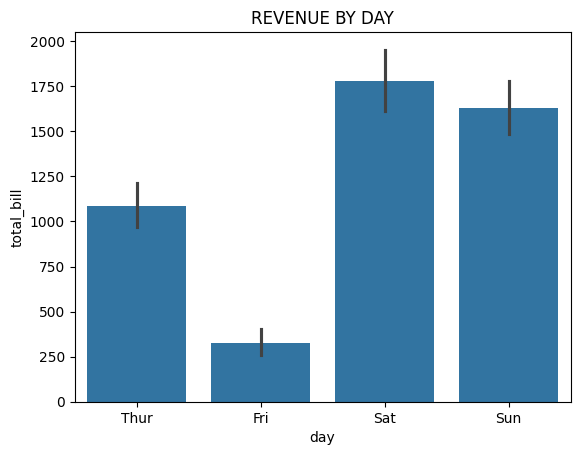

In [40]:
sns.barplot(x="day",y="total_bill",data=df,estimator=sum)
plt.title("REVENUE BY DAY")
plt.show()

2.revenue by time

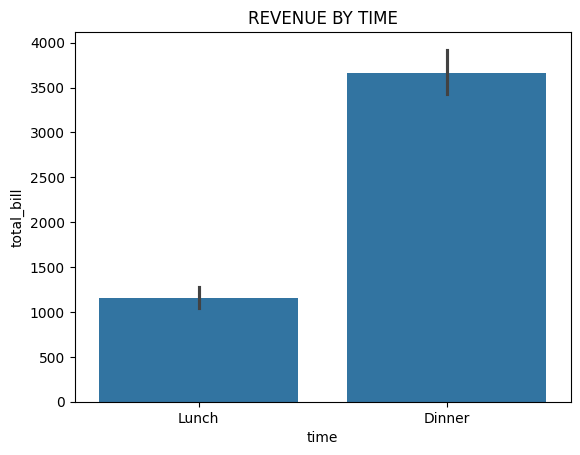

In [41]:
sns.barplot(x='time',y='total_bill',data=df,estimator=sum)
plt.title("REVENUE BY TIME")
plt.show()

3.tip percentage distribution

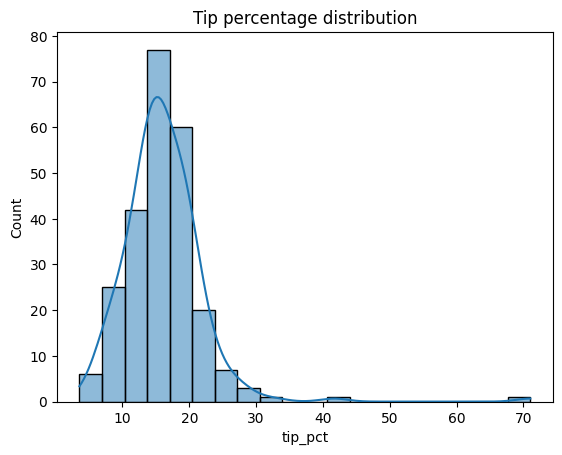

In [42]:
sns.histplot(df['tip_pct'],bins=20,kde=True)
plt.title("Tip percentage distribution")
plt.show()

4.total bill vs tip

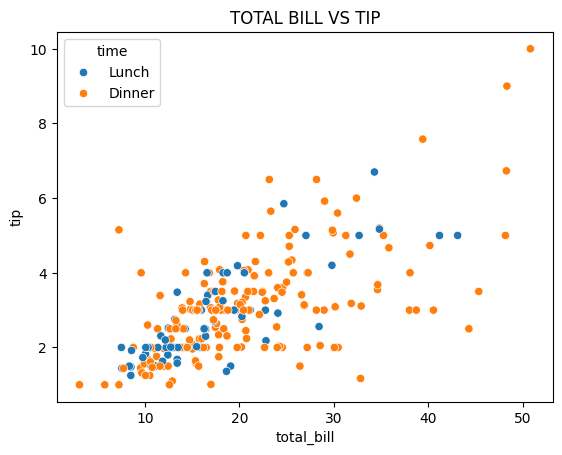

In [43]:
sns.scatterplot(x="total_bill",y="tip",hue="time",data=df)
plt.title("TOTAL BILL VS TIP")
plt.show()

5.revenue by gender

<Axes: xlabel='sex', ylabel='total_bill'>

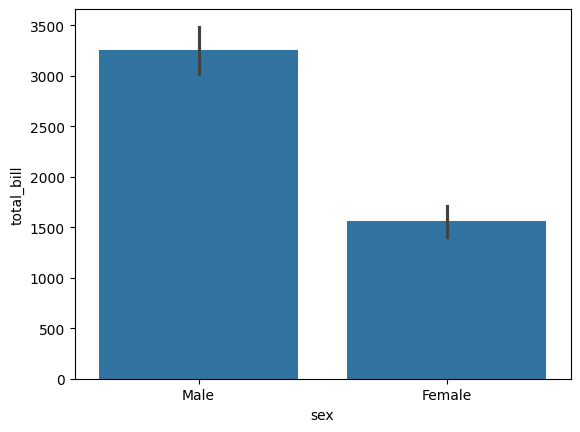

In [44]:
sns.barplot(x="sex",y="total_bill",data=df,estimator=sum)

6.revenue by size

<Axes: xlabel='size', ylabel='total_bill'>

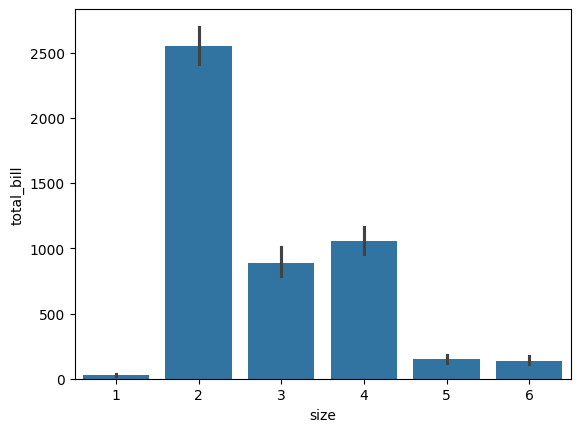

In [45]:
sns.barplot(x="size",y="total_bill",data=df,estimator=sum)

7.day + time revenue

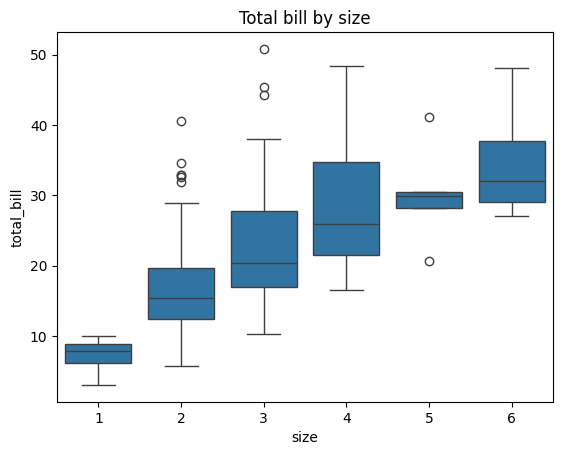

In [46]:
sns.boxplot(x="size",y="total_bill",data=df)
plt.title("Total bill by size")
plt.show()

<Axes: xlabel='day', ylabel='total_bill'>

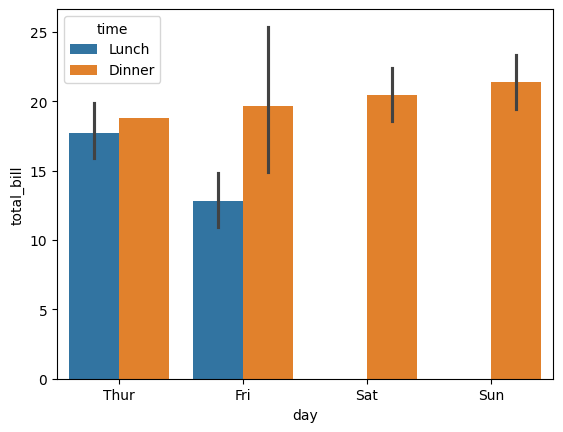

In [47]:
sns.barplot(x="day",y="total_bill",hue="time",data=df)

<Axes: xlabel='day', ylabel='total_bill'>

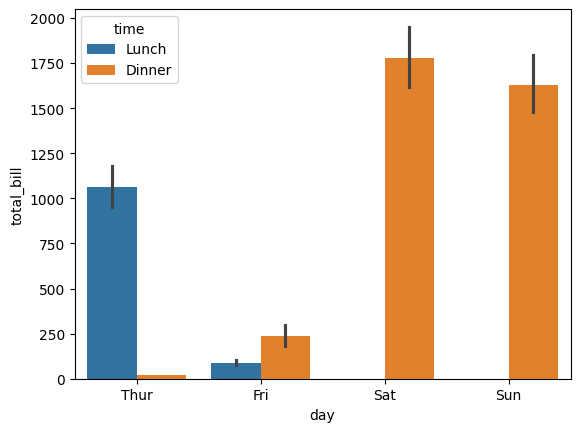

In [48]:
sns.barplot(x="day",y="total_bill",hue="time",data=df,estimator=sum)

insights:

- saturday and sunday we will have highest sales

- dinner time will generate highest sales as compared to lunch time

- larger size people will get higher bills

- male visits the restaurant more as compared to female

- tip percentage will be mostly around 10-20%

Static dashboard:

In [49]:
import pandas as pd
import plotly.express as px

# LOAD DATASET
df = px.data.tips()

# DATA PREPARATION
df['tip_pct'] = (df['tip'] / df['total_bill']) * 100

#  KPIs

total_revenue = df['total_bill'].sum()
total_tips = df['tip'].sum()
avg_tip_pct = df['tip_pct'].mean()
avg_bill = df['total_bill'].mean()

peak_revenue_day = df.groupby('day')['total_bill'].sum().idxmax()

revenue_by_time = df.groupby('time')['total_bill'].sum()

smoking_revenue = df.groupby('smoker')['total_bill'].sum()

print("Total Revenue:", total_revenue)
print("Total Tips Collected:", total_tips)
print("Average Tip %:", avg_tip_pct)
print("Average Bill:", avg_bill)
print("Peak Revenue Day:", peak_revenue_day)
print("\nRevenue by Time:\n", revenue_by_time)
print("\nSmoking vs Non-Smoking Revenue:\n", smoking_revenue)

# CHARTS
# 1. Revenue by Day
fig1 = px.bar(df, x='day', y='total_bill',
              title='Revenue by Day')

# 2. Revenue by Time
fig2 = px.bar(df, x='time', y='total_bill',
              title='Revenue by Time')

# 3. Tip % Distribution
fig3 = px.histogram(df, x='tip_pct',
                    title='Tip Percentage Distribution')

# 4. Total Bill vs Tip
fig4 = px.scatter(df, x='total_bill', y='tip',
                  title='Total Bill vs Tip')

# 5. Revenue by Gender
fig5 = px.bar(df, x='sex', y='total_bill',
              title='Revenue by Gender')

# 6. Revenue by Size
fig6 = px.bar(df, x='size', y='total_bill',
              title='Revenue by Size')

# 7. Day + Time Revenue
fig7 = px.bar(df, x='day', y='total_bill',
              color='time',
              barmode='group',
              title='Day + Time Revenue')

#  SHOW ALL

fig1.show()
fig2.show()
fig3.show()
fig4.show()
fig5.show()
fig6.show()
fig7.show()

Total Revenue: 4827.77
Total Tips Collected: 731.5799999999999
Average Tip %: 16.08025817225047
Average Bill: 19.78594262295082
Peak Revenue Day: Sat

Revenue by Time:
 time
Dinner    3660.30
Lunch     1167.47
Name: total_bill, dtype: float64

Smoking vs Non-Smoking Revenue:
 smoker
No     2897.43
Yes    1930.34
Name: total_bill, dtype: float64


build a dashboard by using plotly and dash framework

Create documentation on the same